In [232]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [10]:
load_df = pd.read_csv("./datasets/Salary_Data.csv")

In [108]:
df = pd.DataFrame(load_df)

In [110]:
df = df.dropna(subset=["Years of Experience", "Salary"])

In [111]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [256]:
perm = np.random.permutation(df.shape[0])

In [257]:
X = df["Years of Experience"].values[perm]
y = df["Salary"].values[perm]

In [280]:
import importlib
import models

importlib.reload(models)

from models import *

In [281]:
stat_kit = StatKit()
model_kit = ModelKit()

In [282]:
X_train, X_test = model_kit.split_data(X, 0.8)
y_train, y_test = model_kit.split_data(y, 0.8)

X_train_scaled = stat_kit.standardize(X_train)[0]
X_test_scaled, X_test_mean, X_test_std = stat_kit.standardize(X_test)

In [283]:
simple_model = SLR(np.array([X_train_scaled, y_train]))

print("model parameters m and b: ", simple_model.get_params())

model parameters m and b:  (np.float64(42742.45183866922), np.float64(115304.46631834298))


In [284]:
y_pred = simple_model.predict(X_test_scaled)

In [285]:
model_kit.MAE(y_pred, y_test)

np.float64(25836.991423730975)

In [286]:
X_test_descaled = X_test_scaled * X_test_std + X_test_mean

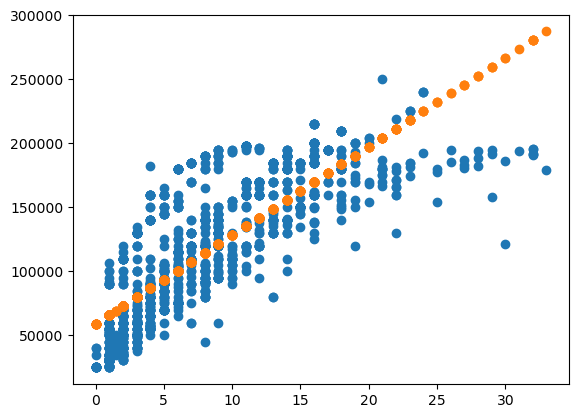

In [287]:
plt.scatter(X_test_descaled, y_test)
plt.scatter(X_test_descaled, y_pred)